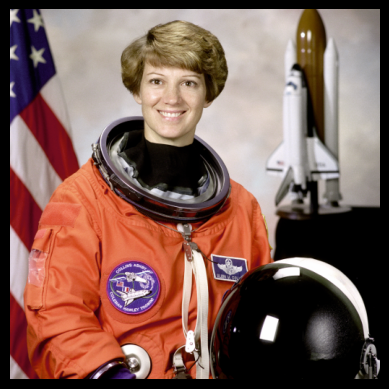

In [1]:
import matplotlib.pyplot as plt
import skimage as skimg
from PIL import Image

#load an image from skimage
img = skimg.data.astronaut()
#alternative load load an image from PIL
# img = Image.open("your_image.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

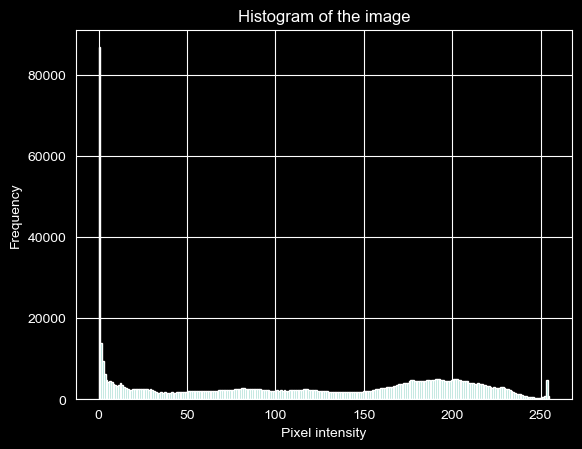

In [2]:
#histogram of the image
plt.hist(img.ravel(), bins=256, range=(0, 255))
plt.title("Histogram of the image")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.show()

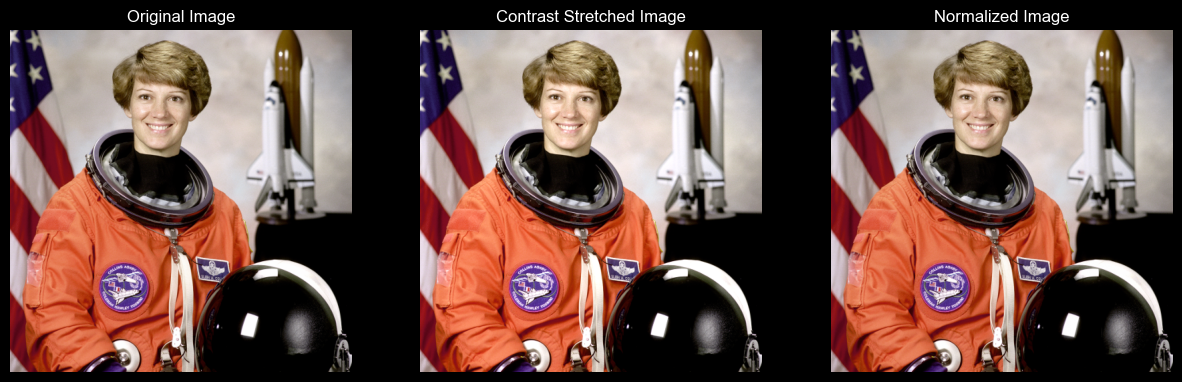

In [3]:
import numpy as np
#contrast and normalization
#contrast stretching
def contrast_stretching(image):
    p2, p98 = np.percentile(image, (2, 98))
    return skimg.exposure.rescale_intensity(image, in_range=(p2, p98))
#normalization
def normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))
#apply contrast stretching
contrast_img = contrast_stretching(img)
#apply normalization
normalized_img = normalize(img)
#display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(contrast_img)
axes[1].set_title("Contrast Stretched Image")
axes[1].axis("off")
axes[2].imshow(normalized_img)
axes[2].set_title("Normalized Image")
axes[2].axis("off")
plt.show()

/Users/gabriel/anaconda3/envs/mlenv/lib/python3.12/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Users/gabriel/anaconda3/envs/mlenv/lib/python3.12/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Users/gabriel/anaconda3/envs/mlenv/lib/python3.12/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


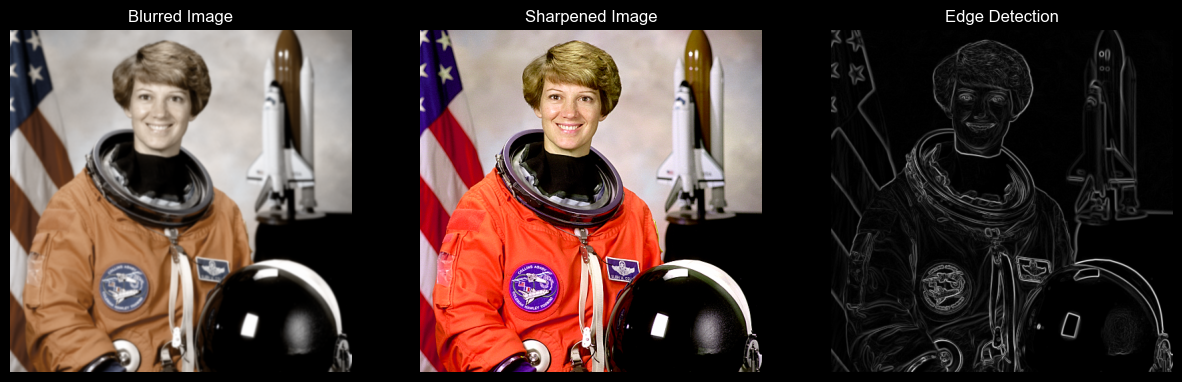

In [4]:
# blur, sharpening, and edge detection
from skimage import filters
#blur
blurred_img = filters.gaussian(img, sigma=1)
#sharpening
sharpened_img = filters.unsharp_mask(img, radius=1, amount=1)
#edge detection
edges = filters.sobel(skimg.color.rgb2gray(img))
#display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(blurred_img)
axes[0].set_title("Blurred Image")
axes[0].axis("off")
axes[1].imshow(sharpened_img)
axes[1].set_title("Sharpened Image")
axes[1].axis("off")
axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Edge Detection")
axes[2].axis("off")
plt.show()

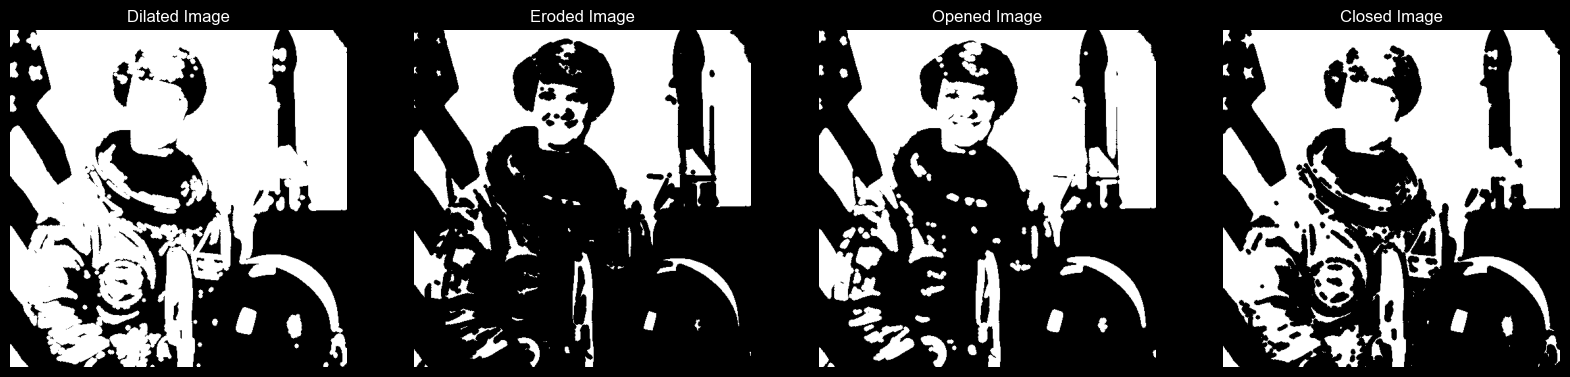

In [5]:
#morphological operations
from skimage import morphology
#convert to grayscale
gray_img = skimg.color.rgb2gray(img)
#thresholding to create binary image
binary_img = gray_img > 0.5
#dilation
dilated_img = morphology.dilation(binary_img, morphology.disk(3))
#erosion
eroded_img = morphology.erosion(binary_img, morphology.disk(3))
#opening
opened_img = morphology.opening(binary_img, morphology.disk(3))
#closing
closed_img = morphology.closing(binary_img, morphology.disk(3))
#display results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(dilated_img, cmap="gray")
axes[0].set_title("Dilated Image")
axes[0].axis("off")
axes[1].imshow(eroded_img, cmap="gray")
axes[1].set_title("Eroded Image")
axes[1].axis("off")
axes[2].imshow(opened_img, cmap="gray")
axes[2].set_title("Opened Image")
axes[2].axis("off")
axes[3].imshow(closed_img, cmap="gray")
axes[3].set_title("Closed Image")
axes[3].axis("off")
plt.show()

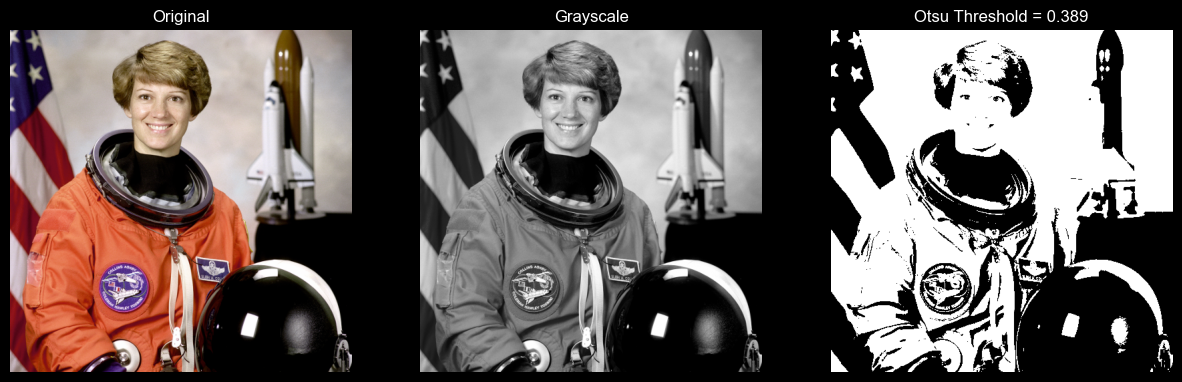

In [6]:
from skimage import filters

# img = skimg.data.astronaut()

# Convert to grayscale
gray_img = skimg.color.rgb2gray(img)

# Otsu threshold
otsu_thresh = filters.threshold_otsu(gray_img)

# Binary image
binary_otsu = gray_img > otsu_thresh

# Show results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray_img, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(binary_otsu, cmap="gray")
axes[2].set_title(f"Otsu Threshold = {otsu_thresh:.3f}")
axes[2].axis("off")

plt.show()

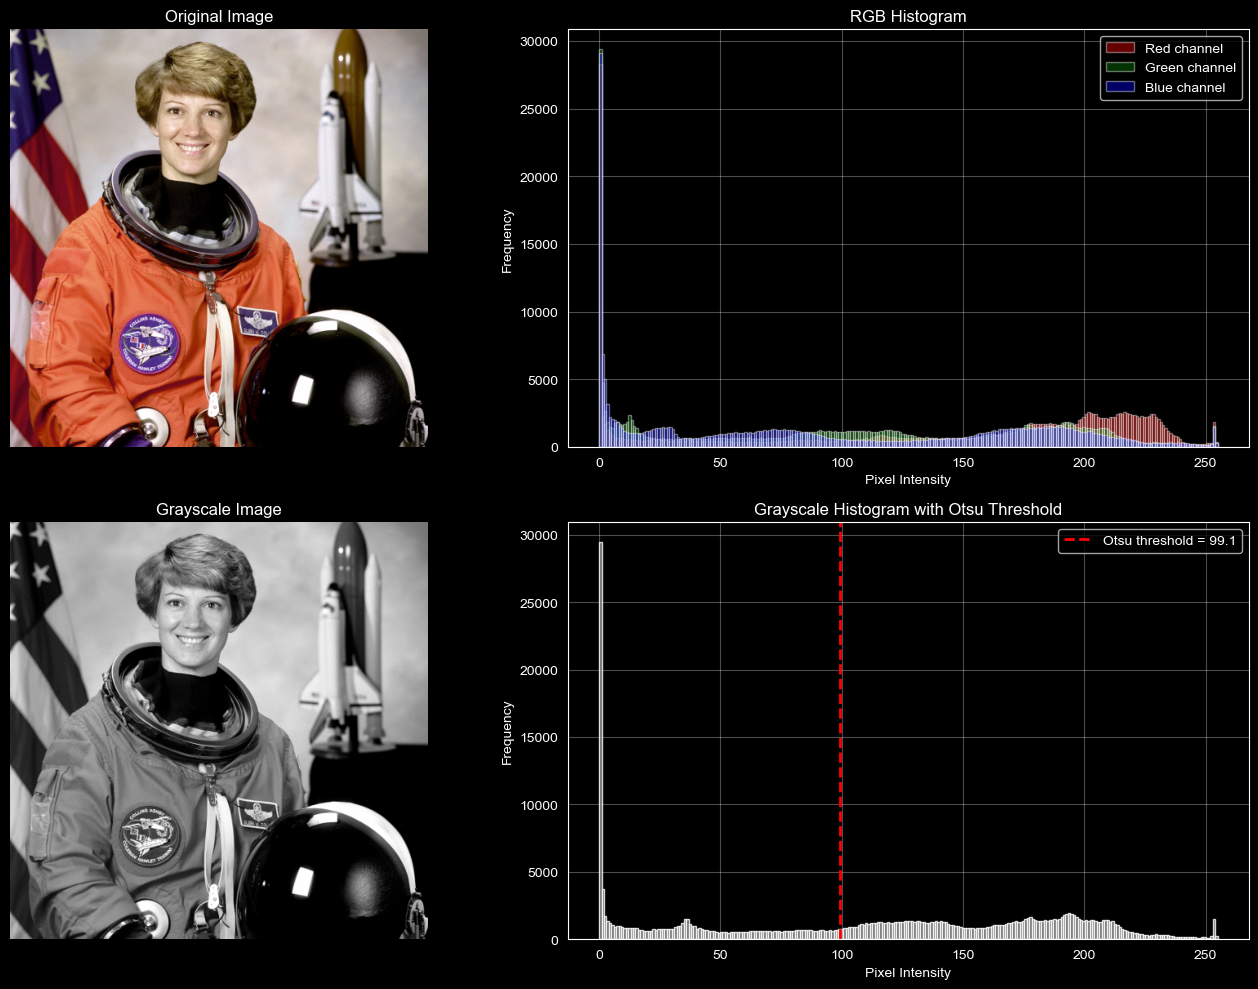

In [7]:
gray_img = skimg.color.rgb2gray(img)

# Convert grayscale to 0-255 for easier interpretation
gray_255 = (gray_img * 255).astype(np.uint8)

# Otsu threshold
otsu_thresh = filters.threshold_otsu(gray_img)
otsu_thresh_255 = otsu_thresh * 255

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axes[0, 0].imshow(img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# RGB histogram
colors = ['red', 'green', 'blue']
labels = ['Red channel', 'Green channel', 'Blue channel']

for i, (color, label) in enumerate(zip(colors, labels)):
    axes[0, 1].hist(
        img[:, :, i].ravel(),
        bins=256,
        range=(0, 255),
        color=color,
        alpha=0.4,
        label=label
    )

axes[0, 1].set_title("RGB Histogram")
axes[0, 1].set_xlabel("Pixel Intensity")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Grayscale image
axes[1, 0].imshow(gray_img, cmap="gray")
axes[1, 0].set_title("Grayscale Image")
axes[1, 0].axis("off")

# Grayscale histogram with Otsu threshold
axes[1, 1].hist(
    gray_255.ravel(),
    bins=256,
    range=(0, 255),
    color="gray",
    alpha=0.8
)
axes[1, 1].axvline(
    otsu_thresh_255,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Otsu threshold = {otsu_thresh_255:.1f}"
)
axes[1, 1].set_title("Grayscale Histogram with Otsu Threshold")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()